#Comparison of Machine Learning Models Under Missing Data

## Introduction

Previous experiments evaluated the effect of missing data on three machine learning algorithms separately:

- Logistic Regression
- Decision Tree
- Random Forest

This experiment combines the results to compare the robustness of different models under increasing levels of missing data.

The objective is to determine which classifier maintains the highest predictive performance when the dataset becomes incomplete.

## Import Libraries

The following libraries are required for loading the experimental results and creating comparison visualizations.

In [5]:
import pandas as pd

import matplotlib.pyplot as plt

## Load Experimental Results

The evaluation results obtained from previous experiments are loaded for comparison.

Each file contains the performance of one machine learning algorithm under different levels of missing data.

In [8]:
logistic = pd.read_csv("logistic_regression_missing_data.csv")

decision_tree = pd.read_csv("decision_tree_missing_data.csv")

random_forest = pd.read_csv("random_forest_missing_data.csv")

## Label Each Model

A new column is added to each DataFrame to identify which machine learning algorithm produced the corresponding results.

This will allow all experiments to be combined into a single comparison table.

In [9]:
logistic["Model"] = "Logistic Regression"

decision_tree["Model"] = "Decision Tree"

random_forest["Model"] = "Random Forest"

## Combine All Results

The three experimental result tables are merged into a single DataFrame.

This allows all machine learning models to be compared within one table.

In [10]:
comparison = pd.concat([logistic, decision_tree, random_forest ],ignore_index=True)

comparison

,Missing Data,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive,Model
0,0%,0.804,0.783,0.730,0.755,90,15,20,54,Logistic Regression
1,10%,0.788,0.757,0.716,0.736,88,17,21,53,Logistic Regression
2,20%,0.777,0.743,0.703,0.722,87,18,22,52,Logistic Regression
3,30%,0.777,0.743,0.703,0.722,87,18,22,52,Logistic Regression
4,0%,0.782,0.727,0.757,0.742,84,21,18,56,Decision Tree
5,10%,0.810,0.763,0.784,0.773,87,18,16,58,Decision Tree
6,20%,0.793,0.761,0.730,0.745,88,17,20,54,Decision Tree
7,30%,0.788,0.781,0.676,0.725,91,14,24,50,Decision Tree
8,0%,0.821,0.800,0.757,0.778,91,14,18,56,Random Forest
9,10%,0.799,0.757,0.757,0.757,87,18,18,56,Random Forest


## Compare Model Accuracy

A line chart is created to compare how the Accuracy of each machine learning model changes as the amount of missing data increases.

This visualization makes it easier to identify which algorithm is the most robust.

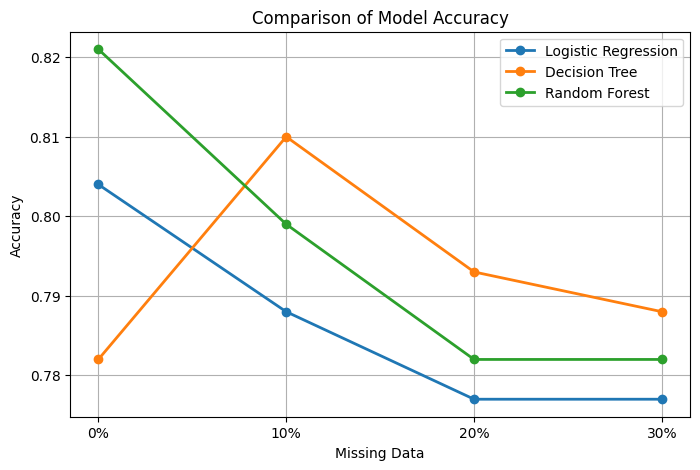

In [12]:
plt.figure(figsize=(8,5))

for model in comparison["Model"].unique():

    data = comparison[comparison["Model"] == model]

    plt.plot(data["Missing Data"], data["Accuracy"],marker="o", linewidth=2,label=model)

plt.xlabel("Missing Data")

plt.ylabel("Accuracy")

plt.title("Comparison of Model Accuracy")

plt.grid(True)

plt.legend()

plt.savefig("model_accuracy_comparison.png")

plt.show()

## Compare F1-score

The F1-score is compared across all machine learning models under different levels of missing data.

Unlike Accuracy, the F1-score considers both Precision and Recall, providing a more balanced evaluation of model performance.

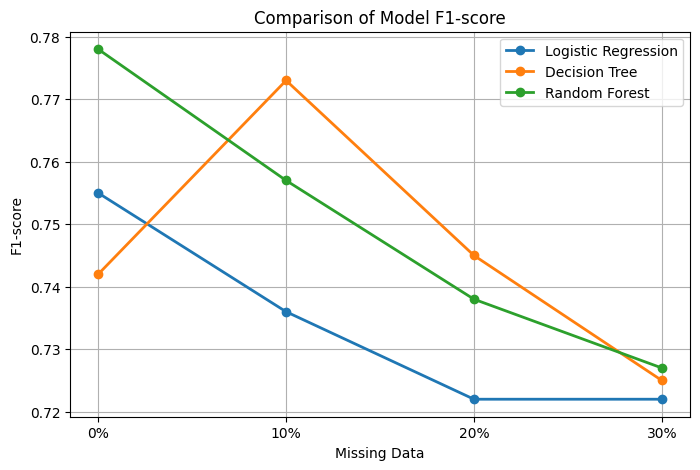

In [14]:
plt.figure(figsize=(8,5))

for model in comparison["Model"].unique():

    data = comparison[comparison["Model"] == model ]

    plt.plot( data["Missing Data"],data["F1-score"], marker="o",linewidth=2, label=model)

plt.xlabel("Missing Data")

plt.ylabel("F1-score")

plt.title("Comparison of Model F1-score")

plt.grid(True)

plt.legend()

plt.savefig("model_f1_comparison.png")

plt.show()

## Analysis of Results

The comparison shows that all three machine learning models lose performance as the percentage of missing data increases. However, the rate of degradation differs between the algorithms.

Random Forest achieved the highest Accuracy (0.821) and F1-score (0.778) when no missing data were present, making it the strongest model under ideal conditions.

Decision Tree demonstrated the best robustness when 10% of the data were missing. It achieved the highest Accuracy (0.810) and F1-score (0.773), outperforming both Logistic Regression and Random Forest at this level of missing data.

As the percentage of missing data increased to 20% and 30%, the performance of all models decreased. Decision Tree generally maintained a slight advantage, while Logistic Regression produced the lowest scores across most experiments.

Overall, tree-based models handled incomplete data better than Logistic Regression, suggesting that they are more robust when working with datasets containing missing values.

## Conclusion

This experiment compared the robustness of three machine learning algorithms under different levels of missing data.

Random Forest produced the highest performance on the complete dataset, while Decision Tree showed the greatest stability when moderate amounts of missing data were introduced.

Logistic Regression experienced the largest overall decrease in predictive performance.

These results indicate that tree-based algorithms are generally more resistant to missing values than Logistic Regression, making them a better choice for datasets with incomplete information.